In [20]:
import json

with open('locust_predictions (1).json', 'r') as f:
    locust_predictions = json.load(f)

display(locust_predictions)

[{'name': 'Somalia coast',
  'lat': 11.5,
  'lng': 42.5,
  'risk': 'no',
  'confidence': 56.0},
 {'name': 'Yemen highlands',
  'lat': 15.3,
  'lng': 38.1,
  'risk': 'no',
  'confidence': 58.0},
 {'name': 'Niger Sahel',
  'lat': 9.1,
  'lng': 45.2,
  'risk': 'yes',
  'confidence': 61.9},
 {'name': 'Ethiopia lowlands',
  'lat': 12.8,
  'lng': 41.0,
  'risk': 'no',
  'confidence': 53.9},
 {'name': 'Kenya Rift Valley',
  'lat': 8.4,
  'lng': 44.3,
  'risk': 'no',
  'confidence': 61.9}]

In [21]:
import pandas as pd
import json

with open('locust_predictions (1).json', 'r') as f:
    data = json.load(f)

df = pd.DataFrame(data)
print(df.head())
print(df.shape)

                name   lat   lng risk  confidence
0      Somalia coast  11.5  42.5   no        56.0
1    Yemen highlands  15.3  38.1   no        58.0
2        Niger Sahel   9.1  45.2  yes        61.9
3  Ethiopia lowlands  12.8  41.0   no        53.9
4  Kenya Rift Valley   8.4  44.3   no        61.9
(5, 5)


In [22]:
df['risk_label'] = df['risk'].map({'yes': 1, 'no': 0})
print(df['risk_label'].value_counts())

risk_label
0    4
1    1
Name: count, dtype: int64


In [23]:
pip install folium

In [24]:
import folium

map_center = [df['lat'].mean(), df['lng'].mean()]
m = folium.Map(location=map_center, zoom_start=5)

for _, row in df.iterrows():
    color = 'red' if row['risk'] == 'yes' else 'green'
    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=8,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=f"{row['name']} | Risk: {row['risk']} | Confidence: {row['confidence']}%"
    ).add_to(m)

m.save('locust_map.html')
print("Map saved!")

Map saved!


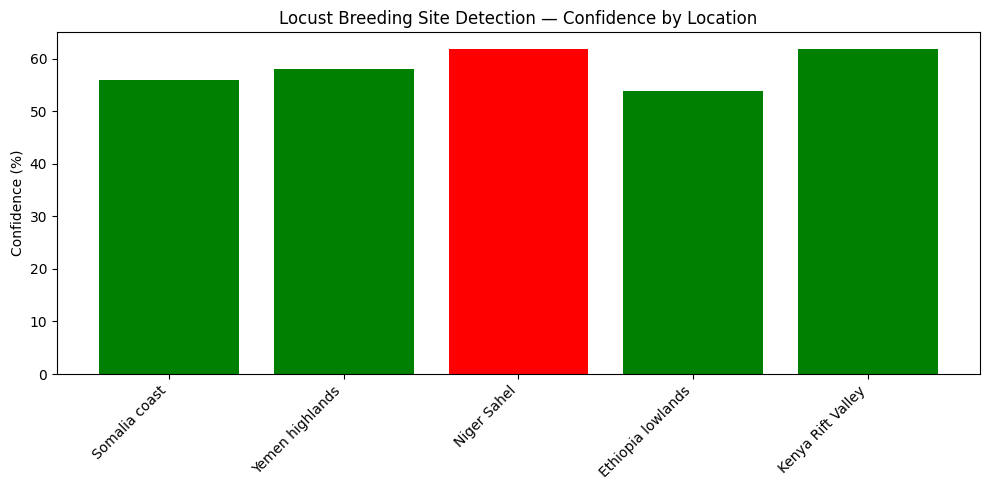

In [25]:
import matplotlib.pyplot as plt

colors = ['red' if r == 'yes' else 'green' for r in df['risk']]
plt.figure(figsize=(10, 5))
plt.bar(df['name'], df['confidence'], color=colors)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Confidence (%)')
plt.title('Locust Breeding Site Detection — Confidence by Location')
plt.tight_layout()
plt.savefig('confidence_chart.png')
plt.show()

In [26]:
df.to_csv('locust_summary.csv', index=False)
print("Summary saved!")

Summary saved!


In [27]:
from google.colab import files
files.download('locust_map.html')
files.download('confidence_chart.png')
files.download('locust_summary.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>